# 1、项目介绍

**现象级互动式电影游戏《底特律：成为人类》大数据分析  
包括标签、玩家在线、价格、评论等多方面分析  
该研究仅具有参考价值，只代表steam平台数据，切勿深究**

# 2、数据收集与预处理
## 2.1数据集介绍  
**本次实验共使用8个数据集，两个数据集来源github开源直到2024年的游戏（类别/名称）数据，  
[github地址:https://github.com/NewbieIndieGameDev/steam-insights](https://github.com/NewbieIndieGameDev/steam-insights)**  
**四个数据集来源steamdb官网数据[steamdb地址:https://steamdb.info/app/1222140/](https://steamdb.info/app/1222140/)  
两个数据集来源爬虫获取（steam官方API插件,确保合法合规爬取），为用户评价与游玩时长  
爬虫代码文件已上传到平台**

## 2.2数据集简介

**1.games.csv数据集**  

| 列名 | 简介 |
| :---: | :---: |
| `app_id`        | 游戏的唯一标识ID |
| `name`          | 游戏的名称|
| `release_date`  | 游戏的正式发布日期 |
| `is_free`       |标识游戏是否免费 |
| `price_overview`| 价格 |
| `languages`     | 游戏支持的语言列表|
| `type`          | 游戏的类型分类 |

**2.tags.csv数据集**  

| 列名 | 简介 |
| --- | --- |
| `app_id` | 游戏唯一ID |
| `tag` | 游戏的标签 |

**3.follow_user.csv数据集**  

| 列名 | 简介 |
| --- | --- |
| `DateTime` | 时间 |
| `Followers` | steambub关注人数 |

**4.online_player.csv数据集**  

| 列索引          | 简介                                                                 |
| :-------------- | :------------------------------------------------------------------- |
| `DateTime`      | 时间|
| `Players`       | 当日在线玩家数量  |
| `Average Players` | 当日平均玩家数量 |

**5.price_history.csv数据集**  

| 列索引          | 简介                                                                 |
| :-------------- | :------------------------------------------------------------------- |
| `DateTime`      | 时间|
| `Final price`       | 当日价格  |
| `History Low` | 历史最低价格 |

**6.review.csv数据集**  

| 列索引          | 简介                                                                 |
| :-------------- | :------------------------------------------------------------------- |
| `DateTime`      | 时间|
| `Positive reviews`       | 当日好评  |
| `Negative reviews` | 当日差评 |

**7.Steam_Detroit_评论数据.csv数据集**  

| 列索引   | 简介                                                                 |
|----------|----------------------------------------------------------------------|
| 页码     | 评论的页码标识             
| 用户ID   | 评论用户的唯一标识    |
| 评论语言 | 评论内容所使用的语言   |
| 用户地区 | 评论用户所属的区域     |
| 推荐状态 | 是否推荐该游戏（好评差评）   |
| 评论内容 | 用户发布的核心评论文本，记录用户的具体反馈、体验或意见               |
| 评论时间 | 评论发布的具体时间，被加密 |
| 是否购买 | steam默认只有购买过的用户才能发评价    |
| 帮助数   | 其他用户认为该评论有帮助的投票数量    |

**8.Steam_Detroit_游玩时长数据.csv数据集**  


| 列索引                 | 简介                                                                 |
| :--------------------- | :------------------------------------------------------------------- |
| `用户ID`               | 游戏用户的唯一标识   |
| `页码`                 | 玩家数据分页的页码标识     |
| `游玩时长（小时）`     | 玩家累计的总游玩时长，以小时为单位 |
| `近2周游玩时长（小时）` | 玩家近14天内的游戏游玩时长，以小时为单位 |

## 2.3数据预处理  
### 2.3.1将影视类互动游戏的标签提取出来

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, KBinsDiscretizer, OneHotEncoder
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import warnings
%matplotlib notebook
df = pd.read_csv(
    r"/data/workspace/userfiles/games.csv",  
    sep=",",  # 字段分隔符
    quotechar='"',  # 字段包裹符（CSV标准，用双引号包裹含分隔符的字段）
    escapechar="\\",  # 转义符（处理字段内的双引号）
)
# 验证：查看字段数量是否正确
print(f"基本信息：{df.info()}")
print(df.head())
print("====重复行数量=====")
print("重复行数量为：{}".format(df.duplicated().sum()))
na=df.isnull().any(axis=1).sum()
print(f"空值行数量:{na}")
#已经过github作者处理


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140082 entries, 0 to 140081
Data columns (total 7 columns):
app_id            140082 non-null int64
name              140082 non-null object
release_date      140082 non-null object
is_free           140082 non-null int64
price_overview    140082 non-null object
languages         140082 non-null object
type              140082 non-null object
dtypes: int64(2), object(5)
memory usage: 7.5+ MB
基本信息：None
   app_id                       name release_date  is_free  \
0      10             Counter-Strike   2000-11-01        0   
1      20      Team Fortress Classic   1999-04-01        0   
2      30              Day of Defeat   2003-05-01        0   
3      40         Deathmatch Classic   2001-06-01        0   
4      50  Half-Life: Opposing Force   1999-11-01        0   

                                      price_overview  \
0  {"final": 819, "initial": 819, "currency": "EU...   
1  {"final": 499, "initial": 499, "currency": "EU...   
2  {

**根据个人经验准确界定“交互式电影游戏”并搜索他们的标签**

In [2]:
target_game_names = ["Detroit: become human","two souls","heavy rain","the walking dead","life is strange","until dawn"]

batch_result = []

for game_name in target_game_names:
    # 忽略大小写，避免因大小写不一致匹配失败
    match_condition = df['name'].str.contains(game_name, case=False, na=False)
    matched_rows = df[match_condition]
    
    #处理匹配结果，存入结果列表
    if matched_rows.empty:
        # 未匹配到该游戏
        batch_result.append({
            "查询名称": game_name,
            "游戏编号(app_id)": "未找到",
            "匹配到的游戏名称": "无"
        })
    else:
        # 匹配到结果，提取编号和名称
        for _, row in matched_rows.iterrows():
            batch_result.append({
                "查询名称": game_name,
                "游戏编号(app_id)": row['app_id'],
                "匹配到的游戏名称": row['name']
            })

# 转换结果为DataFrame，格式化输出
result_df = pd.DataFrame(batch_result)
print("=== 批量游戏名称编号查询结果 ===")
print(result_df.to_string())  

#保留需要的行
keep_index = [0, 2, 8,10,25,34]
filtered_df = result_df.loc[keep_index]  # 按index筛选行

# 移除「查询名称」列（只保留原始列）
games_id = filtered_df.drop(columns=["查询名称"])

# 重置索引
games_id = games_id.reset_index(drop=True)

# 6. 输出最终结果
print("\n=== 最终结果（按index筛选+移除查询名称列）===")
print(games_id)

=== 批量游戏名称编号查询结果 ===
                     查询名称  游戏编号(app_id)                                           匹配到的游戏名称
0   Detroit: become human       1222140                              Detroit: Become Human
1   Detroit: become human       1224230                         Detroit: Become Human Demo
2               two souls        960990                                  Beyond: Two Souls
3               two souls       1248980                             BEYOND: Two Souls Demo
4               two souls       1349830                         RONIN: Two Souls CHAPTER 1
5               two souls       2728080                                          Two Souls
6               two souls       2851410                                     Two Souls Demo
7               two souls       2853420                                 Two Souls Playtest
8              heavy rain        960910                                         Heavy Rain
9              heavy rain       1048290                              

### 成功获取游戏名称对应id
**《底特律：成为人类》,《超凡双生》，《暴雨》，《直到黎明》，《行尸走肉》，《奇异人生》**  
**接下来根据id获取对应游戏标签**

In [3]:
#df不需要再用可以覆写
df=pd.read_csv(r"/data/workspace/userfiles/tags.csv",
    sep=",",  # 字段分隔符
    quotechar='"',  # 字段包裹符（CSV标准，用双引号包裹含分隔符的字段）
    escapechar="\\",  # 转义符（处理字段内的双引号）
              )
print(df.head())
print(df.describe()) #查看基本信息
#预处理
print("重复行数量为：{}".format(df.duplicated().sum()))
na=df.isnull().any(axis=1).sum()
print(f"空值行数量:{na}")

   app_id       tag
0      10     1980s
1      10    1990's
2      10    Action
3      10  Assassin
4      10   Classic
             app_id
count  1.744632e+06
mean   1.865601e+06
std    8.305061e+05
min    1.000000e+01
25%    1.259510e+06
50%    1.891740e+06
75%    2.555480e+06
max    3.298710e+06
重复行数量为：0
空值行数量:0


### 连接得到同类游戏标签数据集games_tags_m

In [4]:
#目标游戏tag筛选
games_tags = df[df["app_id"].isin(games_id["游戏编号(app_id)"])]
games_tags = games_tags.reset_index(drop=True)
print(games_tags)
#对标签分组聚合处理
games_tags_m = games_tags.groupby('app_id')['tag'].apply(', '.join).reset_index()
print(games_tags_m)


      app_id                        tag
0     207610                     Action
1     207610                  Adventure
2     207610                Atmospheric
3     207610             Choices Matter
4     207610  Choose Your Own Adventure
..       ...                        ...
115  2172010          Quick-Time Events
116  2172010                     Remake
117  2172010               Singleplayer
118  2172010                 Story Rich
119  2172010               Third Person

[120 rows x 2 columns]
    app_id                                                tag
0   207610  Action, Adventure, Atmospheric, Choices Matter...
1   319630  Action, Adventure, Atmospheric, Casual, Choice...
2   960910  Adventure, Atmospheric, Choices Matter, Cinema...
3   960990  Adventure, Atmospheric, Beautiful, Choices Mat...
4  1222140  Adventure, Atmospheric, Beautiful, Choices Mat...
5  2172010  Adventure, Atmospheric, Choices Matter, Choose...


### 2.3.2处理steamdb的四个数据集

In [5]:
#导入steamhub关注用户数据
df1=pd.read_csv(r"/data/workspace/userfiles/follow_user.csv",encoding="utf-8")
#导入每日在线数据
df2=pd.read_csv(r"/data/workspace/userfiles/online_player.csv",encoding="utf-8")
#导入每日新增评价数据
df3=pd.read_csv(r"/data/workspace/userfiles/review.csv",encoding="utf-8")
df1['DateTime'] = pd.to_datetime(df1['DateTime'], errors='coerce')
df1['DateTime'] = df1['DateTime'].dt.date  # 非日期格式转为标准格式
df1=df1.rename(columns={'DateTime':'Date'})
df2['DateTime'] = pd.to_datetime(df2['DateTime'], errors='coerce')
df2['DateTime'] = df2['DateTime'].dt.date
df2=df2.rename(columns={'DateTime':'Date'})
df3['DateTime'] = pd.to_datetime(df3['DateTime'], errors='coerce')
df3['DateTime'] = df3['DateTime'].dt.date
df3=df3.rename(columns={'DateTime':'Date'})
for d in [df1,df2,df3]:
    print("====基本信息====")
    print(d.info())
    #预处理
    print("重复行数量为：{}".format(d.duplicated().sum())) 
    na=d.isnull().any(axis=1).sum()
    print(f"空值行数量:{na}")
print(df2[df2.duplicated()])

====基本信息====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2042 entries, 0 to 2041
Data columns (total 2 columns):
Date         2042 non-null object
Followers    2042 non-null int64
dtypes: int64(1), object(1)
memory usage: 32.0+ KB
None
重复行数量为：0
空值行数量:0
====基本信息====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3565 entries, 0 to 3564
Data columns (total 3 columns):
Date               3565 non-null object
Players            3545 non-null float64
Average Players    1896 non-null float64
dtypes: float64(2), object(1)
memory usage: 83.7+ KB
None
重复行数量为：17
空值行数量:1673
====基本信息====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2019 entries, 0 to 2018
Data columns (total 3 columns):
Date                2019 non-null object
Positive reviews    1854 non-null float64
Negative reviews    1551 non-null float64
dtypes: float64(2), object(1)
memory usage: 47.4+ KB
None
重复行数量为：0
空值行数量:468
            Date  Players  Average Players
3026  2025-12-24      NaN              NaN
3030  2025-12-

**df1、df3无重复值，df2有重复值、缺失值，  
打印后发现是因为steamdb越靠后统计频率越高，  
但可能有些时候没有获取到数据导致缺失也同时导致了重复行  
而日均在线判定比较复杂，难以复现，也没有更特殊的研究价值，所以将该列舍弃  
df3缺失值是当日无评价，因此应该填0  
然后对三个表进行拼接**

**处理df2缺失值**

In [6]:
#df2在2025.11.28后的数据是1小时1更，所以应该保留日期相同的第一列00:00:00的数据，和前面保持一致
df2.drop_duplicates(subset='Date', keep='first', inplace=True) 
df2=df2.drop(columns="Average Players")
df2.tail()  #删除完毕

,Date,Players
2913,2025-12-24,9104.0
3057,2025-12-25,NaN
3201,2025-12-26,10679.0
3345,2025-12-27,10708.0
3489,2025-12-28,11705.0


In [7]:
print(df2[df2.isnull().any(axis=1)]) 
print(df2.duplicated().sum())
#这里查看数据集，发现这天的数据00:00:00分没有记录，故手动改为最近的在线人数
df2.loc[3057,'Players']=8220
print(df2[df2.isnull().any(axis=1)]) 
print(df2.duplicated().sum())

            Date  Players
3057  2025-12-25      NaN
0
Empty DataFrame
Columns: [Date, Players]
Index: []
0


**处理df3缺失值**

In [8]:
#将df3缺失的值填充为0，即当天没有新评价
df3.fillna(0,inplace=True)
print("=====空白行数量：=====")
print(df3.isnull().any(axis=1).sum()) 

=====空白行数量：=====
0


**合并df1/df2/df3**

In [9]:
df_merged = pd.merge(df1, df2, on='Date', how='outer', suffixes=('_df1', '_df2'))
daily_player_data = pd.merge(df_merged, df3, on='Date', how='outer', suffixes=('', '_df3'))

In [10]:
na=daily_player_data.isnull().any(axis=1).sum()
print(f"空值行数量:{na}")
print(daily_player_data[daily_player_data.isnull().any(axis=1)])
#steam关注可以提前，当时该游戏可能在steam上发售

空值行数量:25
            Date  Followers  Players  Positive reviews  Negative reviews
0     2020-05-26     2237.0      NaN               NaN               NaN
1     2020-05-27     3742.0      NaN               NaN               NaN
2     2020-05-28     4416.0      NaN               NaN               NaN
3     2020-05-29     4813.0      NaN               NaN               NaN
4     2020-05-30     5224.0      NaN               NaN               NaN
5     2020-05-31     5549.0      NaN               NaN               NaN
6     2020-06-01     5889.0      NaN               NaN               NaN
7     2020-06-02     6185.0      NaN               NaN               NaN
8     2020-06-03     6436.0      NaN               NaN               NaN
9     2020-06-04     6825.0      NaN               NaN               NaN
10    2020-06-05     6947.0      NaN               NaN               NaN
11    2020-06-06     7212.0      NaN               NaN               NaN
12    2020-06-07     7449.0      NaN      

**使用外连接是为了处理连接后数据中间部分可能出现的交错空值情况  
但实际看到的是空值行非常连续，观察得知在线玩家与评价数量为空是因为未发售，而最后一天空值是因为28号未更新，因此可以改为使用  
内连接减少处理复杂程度**

In [11]:
df_merged = pd.merge(df1, df2, on='Date', how='inner', suffixes=('_df1', '_df2'))
daily_player_data = pd.merge(df_merged, df3, on='Date', how='inner', suffixes=('', '_df3'))
na=daily_player_data.isnull().any(axis=1).sum()
print(f"空值行数量:{na}")
print(daily_player_data[daily_player_data.isnull().any(axis=1)]) 
#可以看到已经没有空值行了
print(daily_player_data.count())
print(daily_player_data.head())

空值行数量:0
Empty DataFrame
Columns: [Date, Followers, Players, Positive reviews, Negative reviews]
Index: []
Date                2018
Followers           2018
Players             2018
Positive reviews    2018
Negative reviews    2018
dtype: int64
         Date  Followers  Players  Positive reviews  Negative reviews
0  2020-06-19      16437   5720.0             342.0             -37.0
1  2020-06-20      20102   7153.0             524.0             -56.0
2  2020-06-21      22888   7218.0             596.0             -47.0
3  2020-06-22      24879   5872.0             641.0             -28.0
4  2020-06-23      26602   5327.0             431.0             -29.0


**得到daily_player_data连接表**

### 接下来处理df4,即每半个月价格波动  
**由于价格数据集日期跨度相对较大，所以不和以上三个表一起处理，而是单独记录，后面要比较再拿出来**

In [12]:
df4=pd.read_csv(r"/data/workspace/userfiles/price_history.csv")
print(df4.head())
print(df4.describe())
#文件坏了又得重下，所以多了两天数据......
df4['DateTime'] = pd.to_datetime(df4['DateTime'], errors='coerce')
df4['DateTime'] = df4['DateTime'].dt.date  # 非日期格式转为标准格式
df4=df4.rename(columns={'DateTime':'Date'})
print("=====空值行数量=====")
print(df4[df4.isnull().any(axis=1)]) 
df4.drop_duplicates(inplace=True)
print("=====重复行数量=====")
print(df4.duplicated().sum())
#这里通过实际观察发现原数据集2025.6.26一小时统计了两次，而不是一小时价格出现变动
price=df4 #重命名


              DateTime  Final price  Historical Low
0  2020-06-18 10:30:07        115.0           115.0
1  2020-07-09 17:15:47        128.0           115.0
2  2020-09-10 07:05:12        102.0           102.0
3  2020-09-24 07:05:13        128.0           102.0
4  2020-10-29 17:01:20         89.0            89.0
       Final price  Historical Low
count   124.000000      124.000000
mean     92.359677       58.009677
std      38.300353       18.612258
min      13.600000       13.600000
25%      64.000000       38.400000
50%     108.500000       64.000000
75%     128.000000       64.000000
max     136.000000      115.000000
=====空值行数量=====
Empty DataFrame
Columns: [Date, Final price, Historical Low]
Index: []
=====重复行数量=====
0


### 2.3.3处理爬取的评论数据集

In [13]:
#导入玩家评论数据
df1=pd.read_csv(r"/data/workspace/userfiles/Steam_Detroit_评论数据.csv")
print(df1.info())

#接下来去掉页码列和用户地区列（steam已经识别了语言，地区有些用户是隐私不能看到）
df1.drop(columns=["用户地区","页码"],inplace=True)
print("=====空值行数量=====")
print(df1[df1.isnull().any(axis=1)]) 

print("=====重复行数量=====")
print(df4.duplicated().sum())
print(df1.head(1))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211000 entries, 0 to 210999
Data columns (total 9 columns):
页码      211000 non-null int64
用户ID    211000 non-null int64
评论语言    211000 non-null object
用户地区    0 non-null float64
推荐状态    211000 non-null object
评论内容    211000 non-null object
评论时间    211000 non-null int64
是否购买    211000 non-null object
帮助数     211000 non-null int64
dtypes: float64(1), int64(4), object(4)
memory usage: 14.5+ MB
None
=====空值行数量=====
Empty DataFrame
Columns: [用户ID, 评论语言, 推荐状态, 评论内容, 评论时间, 是否购买, 帮助数]
Index: []
=====重复行数量=====
0
                用户ID      评论语言 推荐状态                  评论内容        评论时间 是否购买  \
0  76561199748400909  schinese   推荐  不是，怎么降完又降啊，我玩了还没两个小时  1766101319    是   

   帮助数  
0  196  


In [14]:
#导入玩家游玩数据
df2=pd.read_csv(r"/data/workspace/userfiles/Steam_Detroit_游玩时长数据.csv")
print(df2.info())
print("=====空值行数量=====")
print(df1[df1.isnull().any(axis=1)]) 

print("=====重复行数量=====")
print(df4.duplicated().sum())
df2.drop(columns=["用户ID","页码"],inplace=True)

print(df2.head(1))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211000 entries, 0 to 210999
Data columns (total 4 columns):
用户ID           211000 non-null int64
页码             211000 non-null int64
游玩时长（小时）       211000 non-null float64
近2周游玩时长（小时）    211000 non-null float64
dtypes: float64(2), int64(2)
memory usage: 6.4 MB
None
=====空值行数量=====
Empty DataFrame
Columns: [用户ID, 评论语言, 推荐状态, 评论内容, 评论时间, 是否购买, 帮助数]
Index: []
=====重复行数量=====
0
   游玩时长（小时）  近2周游玩时长（小时）
0      1.85          0.0


### 由于爬虫性质，只是分为两个文件存入
### 直接处理进行concat简单拼接，merge我电脑爆内存....

In [15]:
comments=pd.concat([df1,df2],axis=1)
print(comments.head(1))

                用户ID      评论语言 推荐状态                  评论内容        评论时间 是否购买  \
0  76561199748400909  schinese   推荐  不是，怎么降完又降啊，我玩了还没两个小时  1766101319    是   

   帮助数  游玩时长（小时）  近2周游玩时长（小时）  
0  196      1.85          0.0  


### 对评价时间解密(尝试N次，失败)，并去除冗余列（是否购买，steam必定购买后才能评价）

In [16]:
# import numpy as np
# from datetime import datetime, timezone

# # ----------------------  修正后的时间戳解密函数---------------------
# def decrypt_timestamp(ts, is_millisecond=False, target_tz="Asia/Shanghai"):
#     """
#     解密Steam时间戳（UTC→目标时区），消除DeprecationWarning
#     :param ts: 原始时间戳（int/str/NaN）
#     :param is_millisecond: 是否为毫秒级（13位）
#     :param target_tz: 目标时区（默认中国时区Asia/Shanghai）
#     :return: 格式化时间字符串（YYYY-MM-DD HH:MM:SS）或NaT
#     """
#     # 处理空值/非数值
#     if pd.isna(ts) or not str(ts).isdigit():
#         return pd.NaT
    
#     try:
#         ts_int = int(ts)
#         # 毫秒级转秒级
#         if is_millisecond:
#             ts_int = ts_int // 1000
#         # 转换为UTC时区的datetime（时区感知型）
#         utc_time = datetime.fromtimestamp(ts_int, tz=timezone.utc)
#         # 转换为目标时区（如中国时区UTC+8）
#         local_tz = datetime.now().astimezone().tzinfo if target_tz == "local" else pd.Timestamp.now(tz=target_tz).tz
#         local_time = utc_time.astimezone(local_tz)
        
#         # 格式化输出
#         return local_time.strftime("%Y-%m-%d %H:%M:%S")
#     except (ValueError, OSError):
#         # 处理无效时间戳（如负数、超出范围）
#         return pd.NaT
# #批量解密并替换timestamp列

# # 应用解密函数，替换原列
# comments['评论时间'] = comments['评论时间'].apply(lambda x: decrypt_timestamp(x,True))

# comments['评论时间'] = pd.to_datetime(comments['评论时间'] , errors='coerce')

# # ---------------------- 3. 核心：筛选早于2024年的数据 ----------------------
# # 方法1：直接筛选（推荐，简洁）
# df_before_2024 = comments[comments['评论时间'] < '2024-01-01 00:00:00']
# print("=====空值行数量=====")
# print(comments[comments.isnull().any(axis=1)]) 
# print(df_before_2024)
# print(comments.describe()) 

In [17]:
comments.drop(columns=["是否购买","评论时间"],inplace=True) #评价时间解密失败，无奈舍弃
print(comments.head(1))

                用户ID      评论语言 推荐状态                  评论内容  帮助数  游玩时长（小时）  \
0  76561199748400909  schinese   推荐  不是，怎么降完又降啊，我玩了还没两个小时  196      1.85   

   近2周游玩时长（小时）  
0          0.0  


## 至此，所有数据集已处理完成  
**有games_tags_m标签集、daily_player_data每日玩家数据集、price数据集  
和comments玩家评论数据集**

In [18]:
#games_tags_m数据
print("=====标签数据集=====")
print(games_tags_m.head(2))
t1=len(games_tags_m)
print("总计{}条数据".format(t1))
print("=====每日玩家数据集=====")
print(daily_player_data.head(2))
t2=len(daily_player_data)
print("总计{}条数据".format(t2))
print("=====历史价格数据集=====")
print(price.head(2))
t3=len(price)
print("总计{}条数据".format(t3))
print("=====玩家评价数据集=====")
print(comments.head(2))
t4=len(comments)
print("总计{}条数据".format(t4))
print("==========================")
print("总计数据量:{}".format(t1+t1+t3+t4))

=====标签数据集=====
   app_id                                                tag
0  207610  Action, Adventure, Atmospheric, Choices Matter...
1  319630  Action, Adventure, Atmospheric, Casual, Choice...
总计6条数据
=====每日玩家数据集=====
         Date  Followers  Players  Positive reviews  Negative reviews
0  2020-06-19      16437   5720.0             342.0             -37.0
1  2020-06-20      20102   7153.0             524.0             -56.0
总计2018条数据
=====历史价格数据集=====
         Date  Final price  Historical Low
0  2020-06-18        115.0           115.0
1  2020-07-09        128.0           115.0
总计123条数据
=====玩家评价数据集=====
                用户ID      评论语言 推荐状态  \
0  76561199748400909  schinese   推荐   
1  76561198871833476   english   推荐   

                                                评论内容  帮助数  游玩时长（小时）  \
0                               不是，怎么降完又降啊，我玩了还没两个小时  196      1.85   
1  An interactive and uniquely cinematic sci-fi d...  155     19.95   

   近2周游玩时长（小时）  
0          0.0  
1          0.0  

## 3.大数据可视化分析  
### 按照标签出现频次绘制互动电影式游戏标签词云图

标签频次统计（前10）：
Adventure: 6次
Atmospheric: 6次
Choices Matter: 6次
Singleplayer: 6次
Story Rich: 6次
Emotional: 5次
Third Person: 5次
Quick-Time Events: 4次
Multiple Endings: 4次
Cinematic: 4次


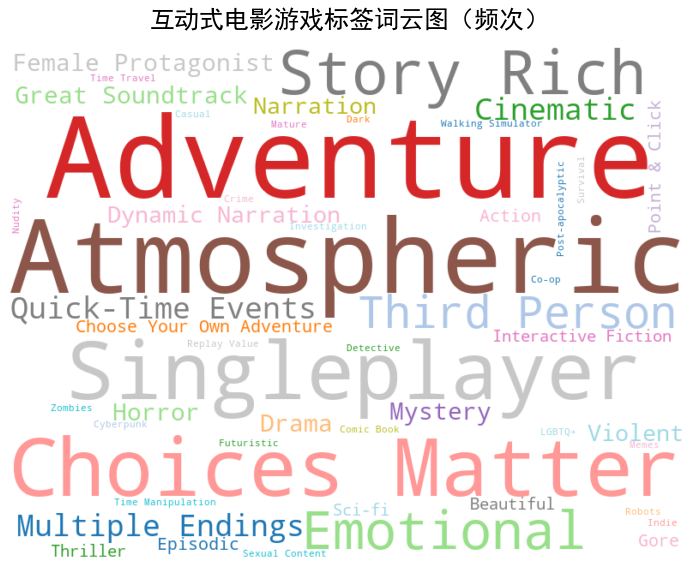

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter
import re
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

def split_count():
    #拆分标签
    a_tags = []
    for tag_str in games_tags_m["tag"]:
        # 正则匹配逗号作为分隔符
        tags = re.split(r',\s*', tag_str.strip())
        a_tags.extend(tags)
    #统计标签频次
    tag_counter = Counter(a_tags)
    tag_freq = dict(tag_counter)
    
    # 打印频次
    print("标签频次统计（前10）：")
    for tag, freq in sorted(tag_freq.items(), key=lambda x: x[1], reverse=True)[:10]:
        print(f"{tag}: {freq}次")
    
    return tag_freq

def generate_tag_wordcloud(tag_freq):
    wc = WordCloud(
        width=800, height=600,  # 词云尺寸
        background_color="white",# 背景色
        max_words=50,            # 最多显示标签数
        colormap="tab20",        # 配色方案（适合英文标签）
        relative_scaling=0.8,    # 字体大小与频次关联度
        random_state=32,         # 固定布局，便于复现 
    ).generate_from_frequencies(tag_freq)

    # 绘制词云
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")  # 隐藏坐标轴
    plt.title("互动式电影游戏标签词云图（频次）", fontsize=25, pad=20)
    plt.tight_layout()
    plt.show()

tag_frequency = split_count()
generate_tag_wordcloud(tag_frequency)

结论：在所有（本人认为是）互动式电影游戏的标签中，`选择十分重要`、`富有美感的`、`多重结局`等标签是这类游戏的共性，  
具有这些游戏标签的游戏更可能成为（我心目中的）电影互动式游戏，同时也能排除掉一些相似但不是电影式（如小说式）的游戏

### 绘制销量漏斗图  
### 该数据来源于《底特律：成为人类》开发公司Quantitic Dream官网  
[https://blog.quanticdream.com/11-million-sales-for-detroit-become-human/](https://blog.quanticdream.com/11-million-sales-for-detroit-become-human/)

In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
from pyecharts import options as opts
from pyecharts.charts import Funnel, Line, Timeline
from datetime import datetime, timedelta
from pyecharts.globals import ThemeType

#底特律：成为人类2024年官方已卖出销量
sell = [["2024年初", 900],["2024秋季",1000],["2024年末", 1100]]


funnel = (
        Funnel()
        .add(
            series_name="销量（万份）",
            data_pair=sell,
            sort_="ascending",  # 升序（漏斗从上到下递增）
            label_opts=opts.LabelOpts(position="inside")
        )
        .set_global_opts(
            title_opts=opts.TitleOpts(title="2024年游戏销量漏斗图", subtitle="单位：万份",pos_left="center"),
            legend_opts=opts.LegendOpts(pos_left="left", orient="vertical")
        )
    )
funnel.render_notebook()

#头歌上能显示，本地显示不了

/usr/local/lib/python3.6/site-packages/pyecharts/charts/chart.py:14: PendingDeprecationWarning: pyecharts 所有图表类型将在 v1.9.0 版本开始强制使用 ChartItem 进行数据项配置 :)
  super().__init__(init_opts=init_opts)


**提出问题：2024的销量变化巨大，尤其是2024年末  
因此接下来几项研究来探究背后的原因  
（一个游戏的历史销量是不能搜索到的，这已经是最接近实际数据的一步了，尽管只有3个数据）**

### 绘制价格变化与历史最低价格折线图

/usr/local/lib/python3.6/site-packages/pandas/plotting/_matplotlib/converter.py:103: FutureWarning: Using an implicitly registered datetime converter for a matplotlib plotting method. The converter was registered by pandas on import. Future versions of pandas will require you to explicitly register matplotlib converters.

To register the converters:
	>>> from pandas.plotting import register_matplotlib_converters
	>>> register_matplotlib_converters()
  warnings.warn(msg, FutureWarning)


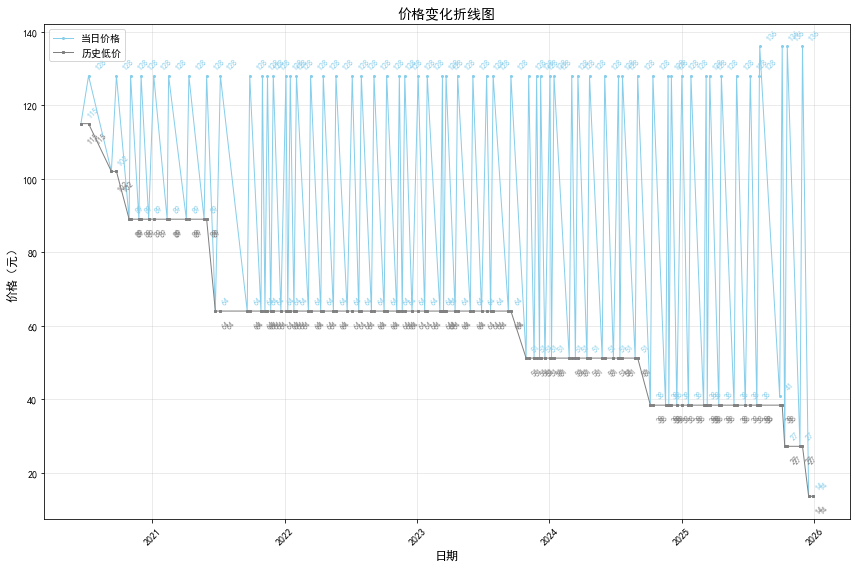

In [21]:
fig1, ax1 = plt.subplots(figsize=(12,8))
line1,=ax1.plot(price['Date'], price['Final price'], marker='o', color='skyblue', label='当日价格')
line2,=ax1.plot(price['Date'], price['Historical Low'], marker='s', color='gray', label='历史低价')
line1.set_linewidth(1)
line1.set_markersize(2)
line2.set_linewidth(1)
line2.set_markersize(2)
ax1.set_title('价格变化折线图', fontsize=14)
ax1.set_xlabel('日期', fontsize=12)
ax1.set_ylabel('价格（元）', fontsize=12)
for x, y in zip(price['Date'], price['Final price']):
    ax1.annotate(f'{y:.0f}', 
                xy=(x, y),                
                xytext=(5, 5),           
                textcoords='offset points',
                fontsize=8,               
                color='skyblue',             
                ha='left',               
                va='bottom',
                rotation=45)              


for x, y in zip(price['Date'], price['Historical Low']):
   
    ax1.annotate(f'{y:.0f}', 
                xy=(x, y),
                xytext=(5, -8),          
                textcoords='offset points',
                fontsize=8,
                color='gray',
                ha='left',
                va='top',
                rotation=45)
ax1.legend()
ax1.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

分析：steamdb的统计数据非连续，底特律的价格波动大是因为steam经常进行促销活动  
结论：随着时间推移，折扣力度越来越大，说明游戏开发商会根据时间与游戏热度变化实时调整价格，且  
越往后会通过更大的优惠来达到吸引新玩家的目的。  
而最近售价的暴跌（骨折价14元），也和前面的突然升到历史最高价形成呼应

**提出问题：2024的销量暴涨，是否和2024的价格波动有关？** 
### 绘制2024年价格柱形图

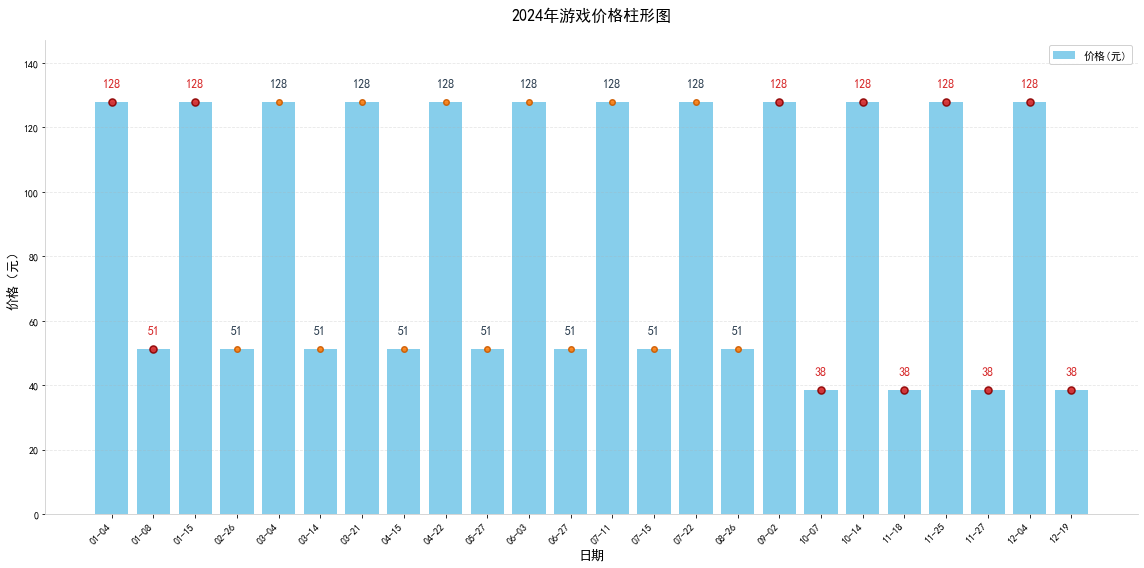

原始数据总条数：123
2024年数据条数：24
2024年数据日期范围：2024-01-04 至 2024-12-19


In [22]:
price['Date'] = pd.to_datetime(price['Date'])  # 转换为datetime格式
price_2024 = price[price['Date'].dt.year == 2024].copy()

# 重置索引（避免x轴坐标不连续）
price_2024 = price_2024.reset_index(drop=True)

fig2,ax2 = plt.subplots(figsize=(16,8))  # 加大画布尺寸，适配更多数据

# 绘制价格柱形图（仅2024年数据）
x = range(len(price_2024))
bars = ax2.bar(x, price_2024['Final price'], width=0.8, color='skyblue', label='价格(元)')

highlight_months = [1, 9, 10, 11, 12]  # 需要标红的月份

for i, (idx, row) in enumerate(price_2024.iterrows()):
    # 获取月份
    month = row['Date'].month
    
    # 设置点的样式
    if month in highlight_months:
        point_color = '#d62728'  # 深红色
        point_size = 50
        edge_color = '#8b0000'
        label_color = '#d62728'
    else:
        point_color = '#ff7f0e'  # 橙色
        point_size = 30
        edge_color = '#cc5c00'
        label_color = '#2c3e50'
    
    # 绘制数据点（在柱子顶部）
    ax2.scatter(i, row['Final price'], color=point_color, s=point_size, 
                edgecolor=edge_color, alpha=0.9, zorder=6, linewidth=1.5)
    
    # 添加价格标签（优化：避免标签重叠）
    ax2.text(i, row['Final price'] + 4, f'{row["Final price"]:.0f}', 
             ha='center', va='bottom', fontsize=12, fontweight='bold',
             color=label_color, rotation=0)

ax2.set_title('2024年游戏价格柱形图', fontsize=16, fontweight='bold', pad=20)
ax2.set_xlabel('日期', fontsize=13, fontweight='500')
ax2.set_ylabel('价格（元）', fontsize=13, fontweight='500')

# 设置x轴刻度（仅显示2024年数据）
ax2.set_xticks(x)
# 优化日期显示格式，避免拥挤
xtick_labels = [d.strftime('%m-%d') for d in price_2024['Date']]  # 仅显示月-日，更简洁
ax2.set_xticklabels(xtick_labels, rotation=45, ha='right', fontsize=10)

# 设置y轴范围（留出顶部空间给标签）
y_min = 0
y_max = price_2024['Final price'].max() * 1.15
ax2.set_ylim(y_min, y_max)

# 添加图例、网格
ax2.legend(loc='upper right', fontsize=11, framealpha=0.9)
ax2.grid(alpha=0.3, axis='y', linestyle='--', linewidth=0.8)

# 美化边框
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_color('#cccccc')
ax2.spines['bottom'].set_color('#cccccc')

# 调整布局并显示
plt.tight_layout()
plt.show()

# 输出筛选结果信息（便于验证）
print(f"原始数据总条数：{len(price)}")
print(f"2024年数据条数：{len(price_2024)}")
print(f"2024年数据日期范围：{price_2024['Date'].min().strftime('%Y-%m-%d')} 至 {price_2024['Date'].max().strftime('%Y-%m-%d')}")

结论：**2024年初、2024秋季、2024年末（按照官方说法即卖出1000万份后的几周）**  
的数据点已经标红，可以看到在秋季《底特律》的价格确实有创下新低  
短短几周就卖出了年初到秋季相同的100万份有理可据  
不过在不知道具体日期具体销量的前提下这个结论不够严谨，  
但也是唯一的可行分析了

### 在线玩家数与价格、steamhub关注度关系  
**双子图、共享作图**

**该研究旨在通过现有数据分析游戏热度，通过在线玩家反映，探究  
影响游戏热度的因素**

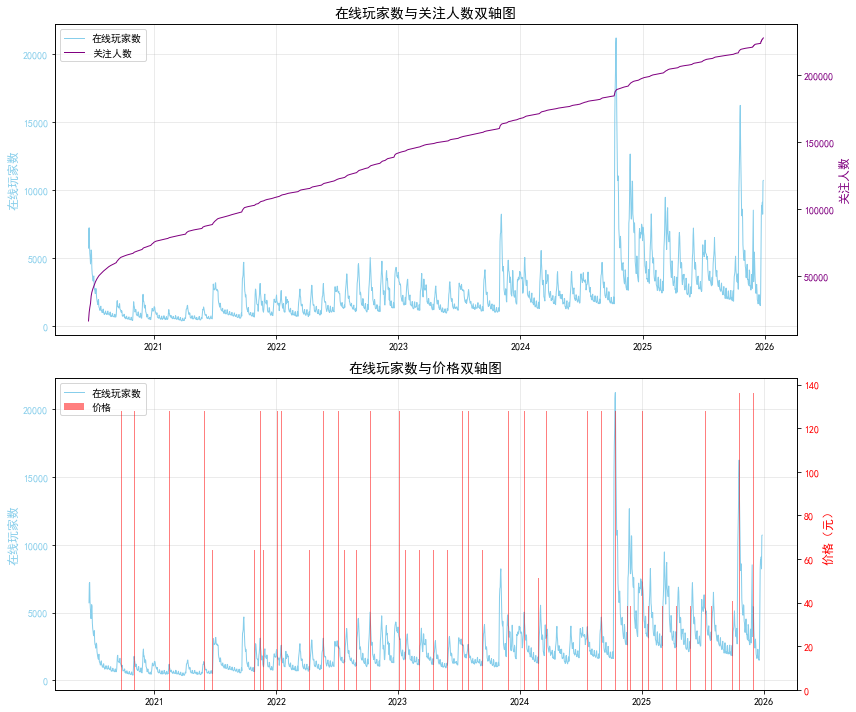

In [23]:
fig3, (ax3_1, ax3_2) = plt.subplots(2, 1, figsize=(12, 10))

# 子图1：Players（左轴） + Followers（右轴）
line1,=ax3_1.plot(daily_player_data['Date'], daily_player_data['Players'], color='skyblue', label='在线玩家数')
ax3_1.set_ylabel('在线玩家数', fontsize=12, color='skyblue')
ax3_1.tick_params(axis='y', labelcolor='skyblue')
ax3_1.set_title('在线玩家数与关注人数双轴图', fontsize=14)
ax3_1.grid(alpha=0.3)
line1.set_linewidth(1)

ax3_1_twin = ax3_1.twinx()
line2,=ax3_1_twin.plot(daily_player_data['Date'], daily_player_data['Followers'], color='purple', label='关注人数')
ax3_1_twin.set_ylabel('关注人数', fontsize=12, color='purple')
ax3_1_twin.tick_params(axis='y', labelcolor='purple')
line2.set_linewidth(1)

# 合并图例
lines1, labels1 = ax3_1.get_legend_handles_labels()
lines2, labels2 = ax3_1_twin.get_legend_handles_labels()
ax3_1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

# 子图2：Players（左轴） + 价格柱形（右轴）
line3,=ax3_2.plot(daily_player_data['Date'], daily_player_data['Players'], color='skyblue', label='在线玩家数')
ax3_2.set_ylabel('在线玩家数', fontsize=12, color='skyblue')
ax3_2.tick_params(axis='y', labelcolor='skyblue')
ax3_2.set_title('在线玩家数与价格双轴图', fontsize=14)
ax3_2.grid(alpha=0.3)

ax3_2_twin = ax3_2.twinx()
ax3_2_twin.bar(price['Date'], price['Final price'], alpha=0.5, color='red', label='价格', width=1)
ax3_2_twin.set_ylabel('价格（元）', fontsize=12, color='red')
ax3_2_twin.tick_params(axis='y', labelcolor='red')
line3.set_linewidth(1)

# 合并图例
lines3, labels3 = ax3_2.get_legend_handles_labels()
lines4, labels4 = ax3_2_twin.get_legend_handles_labels()
ax3_2.legend(lines3 + lines4, labels3 + labels4, loc='upper left')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


结论：通过steamhub不断爬升的热度，对比每日在线玩家数，可以看出  
《底特律变人》的最低在线人数是不断升高的，也照应了关注度的变化趋势  
而价格与每日在线的研究可以看到，当游戏降价促销时，几乎大部分情况下  
每日在线人数都会增多，一定程度上验证了游戏市场规律
**而在图中也明显看到2024年到2025年的在线人数在秋季迎来了大  
爬升，也阶段性地实现了每日最低在线人数的增长，这  
很好地验证了前面提到的销量增长，也从侧面反映  
出了销量会影响日活，同时也说明了该游戏可能在  
2024年秋季获得了一波大热度，个人推测可能是  
由于人工智能的发展，是这部作品有了跨时代的  
讨论度，也迸发了第二春**  
关于时代性的影响，碍于工程量，只能以后有机会再做了

### 2024年玩家评价数热力图  
**每日玩家评价数也是一个很好的反映销量的指标，  
接下来通过绘制热力图进行销量分析**

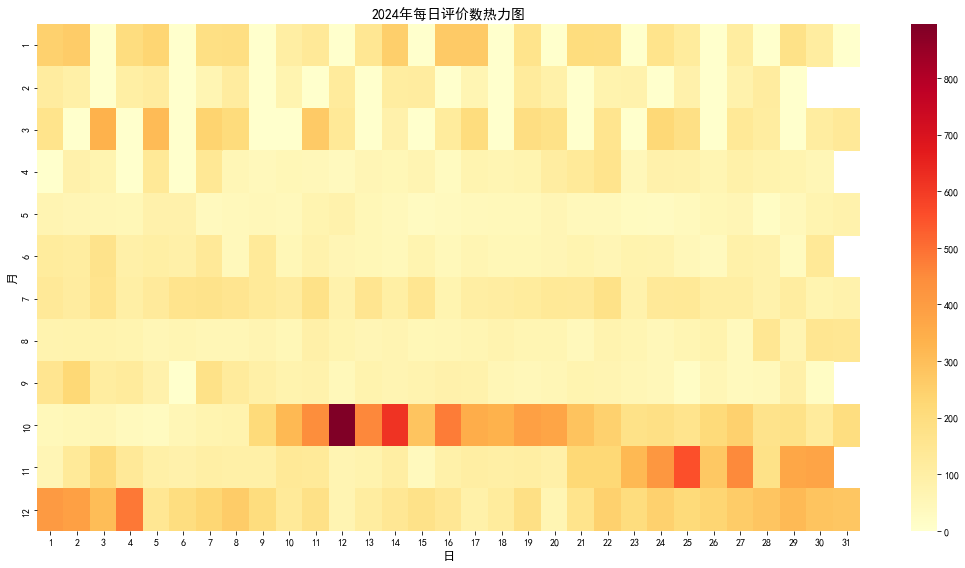

In [24]:
daily_player_data['Date'] = pd.to_datetime(daily_player_data['Date'])  # 转换为datetime格式
rev_2024 = daily_player_data[daily_player_data['Date'].dt.year == 2024].copy()
rev_2024['月'] = rev_2024['Date'].dt.month
rev_2024['日'] = rev_2024['Date'].dt.day
rev_2024['总评价数'] = rev_2024['Positive reviews'] + rev_2024['Negative reviews']

# 透视成热力图格式（月为行，日为列）
heatmap_data = rev_2024.pivot_table(index='月', columns='日', values='总评价数', aggfunc='mean')

fig5, ax5 = plt.subplots(figsize=(15, 8))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=False, fmt='.0f', ax=ax5)
ax5.set_title('2024年每日评价数热力图', fontsize=14)
ax5.set_xlabel('日', fontsize=12)
ax5.set_ylabel('月', fontsize=12)
plt.tight_layout()
plt.show()

结论：可以看到在10月中旬和11月末12月初，每日玩家评价数明显比其他时候  
多，再次验证了官方新闻，**同时也让我们大致确定官方公布的  
24年秋季、24年末（几周后）的大致范围**

研究方向启发
### 推荐与不推荐玩家的游玩时长提琴图  

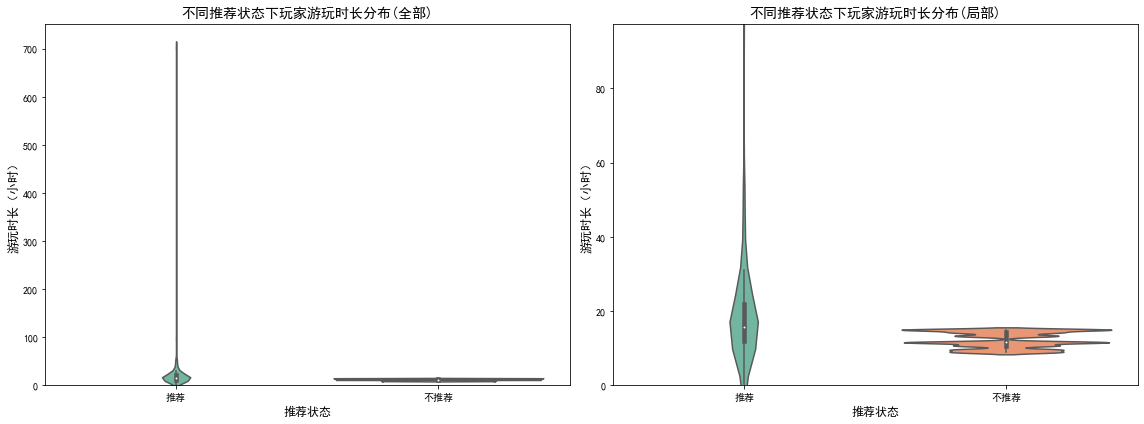

In [33]:
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False
fig6, (ax6_2,ax6_1) = plt.subplots(1,2,figsize=(16, 6))
q1 = comments['游玩时长（小时）'].quantile(0.25)
q3 = comments['游玩时长（小时）'].quantile(0.95)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
sns.violinplot(x='推荐状态', y='游玩时长（小时）', data=comments, ax=ax6_1, palette='Set2')
ax6_1.set_ylim(0,upper_bound)
ax6_1.set_title('不同推荐状态下玩家游玩时长分布(局部)', fontsize=14)
ax6_1.set_xlabel('推荐状态', fontsize=12)
ax6_1.set_ylabel('游玩时长（小时）', fontsize=12)

sns.violinplot(x='推荐状态', y='游玩时长（小时）', data=comments, ax=ax6_2, palette='Set2')
ax6_2.set_title('不同推荐状态下玩家游玩时长分布(全部)', fontsize=14)
ax6_2.set_xlabel('推荐状态', fontsize=12)
ax6_2.set_ylabel('游玩时长（小时）', fontsize=12)
ax6_2.set_ylim(0,)
plt.tight_layout()
plt.show()

结论：经过分析，发现大多数评价玩家游玩时长都聚集在10到20小时之间

提出问题：玩家的评价是否真实(是否有玩家刷差评)  
### 不推荐玩家的游玩时长分布
**该研究旨在通过不同玩家的游玩时长分布  
再根据本人对《底特律》流程各部分时长的熟悉程度，  
判断哪些玩家的评价“可能存疑”**

不推荐玩家游玩时长分组统计：
0-2.5小时         0
0-5小时           0
5-7.5小时         0
7.5-10小时     4220
10-12.5小时    6330
12.5-15小时    6330
15-17.5小时    2110
17.5-20小时       0
20小时以上          0
Name: 时长分组, dtype: int64


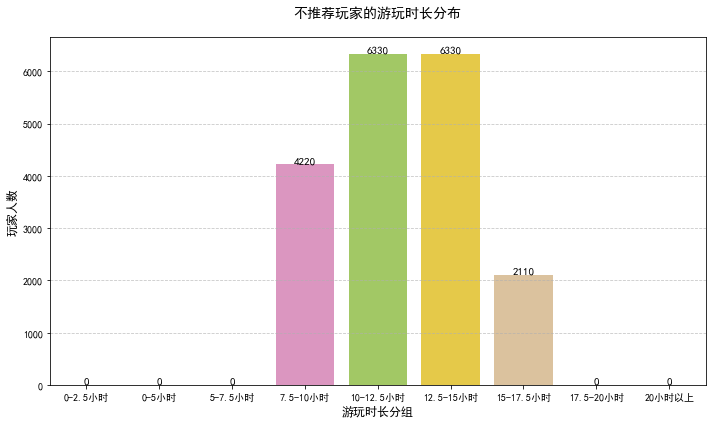

In [26]:
df_not_recommend = comments[comments['推荐状态'] == '不推荐'].copy()

#定义游玩时长分组规则 
# 自定义分组区间
bins = [0,2.5,  5,7.5, 10,12.5,15,17.5,20 ,float('inf')]  # 分组：0-1h、1-5h、5-10h、10h以上
labels = ['0-2.5小时', '0-5小时', '5-7.5小时','7.5-10小时','10-12.5小时','12.5-15小时','15-17.5小时','17.5-20小时','20小时以上']

# 为“不推荐”玩家添加分组列
df_not_recommend['时长分组'] = pd.cut(
    df_not_recommend['游玩时长（小时）'],
    bins=bins,
    labels=labels,
    right=False  # 左闭右开（如0-1小时包含0，不包含1）
)

# 分组聚合统计人数  
group_count = df_not_recommend['时长分组'].value_counts().sort_index()  # 按分组顺序排序
print("不推荐玩家游玩时长分组统计：")
print(group_count)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=group_count.index, y=group_count.values, ax=ax, palette='Set2')

# 添加数值标签（柱形顶部显示人数）
for i, v in enumerate(group_count.values):
    ax.text(i, v + 1, str(v), ha='center', va='bottom', fontsize=11)

# 设置图表标题和标签
ax.set_title('不推荐玩家的游玩时长分布', fontsize=14, pad=20)
ax.set_xlabel('游玩时长分组', fontsize=12)
ax.set_ylabel('玩家人数', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.7)  # 添加横向网格线，提升可读性
plt.tight_layout()  # 自动调整布局
plt.show()


结论：游戏流程大概是10到20小时，随操控主角的数量而递减  
游玩时间落在7.5到12.5小时的玩家可能是过早玩死了自己的角色，  
或者玩死了自己喜欢的角色，游玩时长靠后的玩家可能是  
由于游戏的结局走向不满意，或是游玩到后期不能接受游戏的价值观  
导致。但总体而言并没有发现“刷差评”评价，推测可能是被steam  
屏蔽或被开发者屏蔽

# 注意：运行这段代码后会导致文字显示崩溃，谨慎运行！！
提出研究方向:发掘更多影响是否推荐游戏的因素
### 评价玩家使用语言分布，国内外玩家好评分布（双子图）

/usr/local/lib/python3.6/site-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


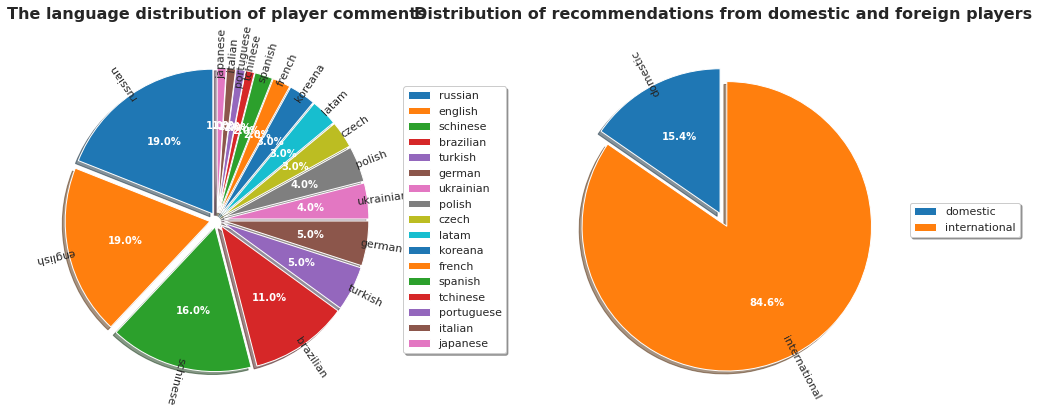

In [34]:
recommend_temp = comments[['评论语言', '推荐状态']]
recommend_temp['地区'] = recommend_temp['评论语言'].apply(lambda x: '国内' if (x == 'schinese' or x=='tchinese')  else '国外')
recommend_region = recommend_temp.groupby(['地区', '推荐状态']).size().unstack(fill_value=0)
sns.set_style("whitegrid")

fig7, (ax7_1, ax7_2) = plt.subplots(1, 2, figsize=(14, 7))
lang_counts = recommend_temp['评论语言'].value_counts()
lang_labels = lang_counts.index

# --------------------- 子图1：评论语言分布饼图 ---------------------
# 绘制饼图
wedges, texts, autotexts = ax7_1.pie(
    lang_counts.values,
    labels=lang_labels,
    autopct='%1.1f%%',
    startangle=90,
    explode=[0.05] * len(lang_counts),  # 轻微分离各部分
    shadow=True,  # 添加阴影
    textprops={'fontsize': 11, 'fontweight': 'medium'}  # 文本样式
)

# 美化百分比文本
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

for i, text in enumerate(texts):
    # 获取文字当前角度并调整旋转
    angle = (wedges[i].theta1 + wedges[i].theta2) / 2
    text.set_rotation(angle)  # 设置标签文字旋转角度
    text.set_horizontalalignment('center')
    text.set_verticalalignment('center')

# 设置标题
ax7_1.set_title('The language distribution of player comments', fontsize=16, fontweight='bold', pad=20)

# 简化图例：只显示语言名称
ax7_1.legend(
    wedges, lang_labels,
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1),
    fontsize=11,
    frameon=True,
    shadow=True
)

# --------------------- 子图2：国内外推荐状态分布 ---------------------
# 绘制饼图
wedges2, texts2, autotexts2 = ax7_2.pie(
    recommend_region['推荐'],
    labels=['domestic', 'international'],
    autopct='%1.1f%%',
    startangle=90,
    explode=[0.05, 0.05],
    shadow=True,
    textprops={'fontsize': 11, 'fontweight': 'medium'}
)

# 美化百分比文本
for autotext in autotexts2:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

for i, text in enumerate(texts2):
    # 获取文字当前角度并调整旋转
    angle = (wedges2[i].theta1 + wedges2[i].theta2) / 2
    text.set_rotation(angle)  # 设置标签文字旋转角度
    text.set_horizontalalignment('center')
    text.set_verticalalignment('center')

# 设置标题
ax7_2.set_title('Distribution of recommendations from domestic and foreign players', fontsize=16, fontweight='bold', pad=20)
#图例
ax7_2.legend(
    wedges2, ['domestic', 'international'],
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1),
    fontsize=11,
    frameon=True,
    shadow=True
)

plt.tight_layout()
plt.subplots_adjust(wspace=0.4)
plt.show()

结论：通过语言侧面映射地区分布（无法爬取），其中在所有给出  
好评的玩家中，国内占比15。4%，国外84.6%  
分析可能是由于意识形态和价值观不同导致  
该游戏偏向和平路线（和平解放）,国内普遍  
接受“枪杆底下出政权”，可能导致这种分布差异  
当然也有可能是国内游玩人数少，云玩现象严重  
这里原本有更多深入研究，可惜同样碍于工程量舍弃（包括国内外价值观分析）

## 4.机器学习部分  
**基于上面研究，最终确定了研究方向  
用机器学习根据玩家评价预测有用数**

### 根据地区、游玩时长、是否推荐预测玩家评价有用数  
**1.玩家评价预处理，分析皮尔逊相关系数**  
对玩家评价地区进行哑变量处理，对是否推荐进行1 0数值化

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 皮尔逊相关性分析 
# 先对类别特征编码（用于相关性分析）
df_corr = comments.copy()
# 对"是否推荐"进行标签编码（推荐=1，不推荐=0）
le = LabelEncoder()
df_corr['推荐状态'] = le.fit_transform(df_corr['推荐状态'])
# 评论语言独热编码
country_dummies = pd.get_dummies(df_corr['评论语言'], prefix='评论语言')
df_corr = pd.concat([df_corr, country_dummies], axis=1)
# 选择数值特征进行相关性分析
numeric_cols = ['推荐状态', '游玩时长（小时）', '帮助数'] + list(country_dummies.columns)
corr_matrix = df_corr[numeric_cols].corr(method='pearson')

# 输出目标变量与各特征的相关性
print("\n帮助数与各特征的皮尔逊相关系数：")
target_corr = corr_matrix['帮助数'].sort_values(ascending=False)
print(target_corr)

/usr/local/lib/python3.6/importlib/_bootstrap.py:205: RuntimeWarning: numpy.ufunc size changed, may indicate binary incompatibility. Expected 192 from C header, got 216 from PyObject
  return f(*args, **kwds)



帮助数与各特征的皮尔逊相关系数：
帮助数                1.000000
游玩时长（小时）           0.295310
评论语言_english       0.194043
评论语言_schinese      0.177420
推荐状态               0.072204
评论语言_spanish       0.030454
评论语言_polish        0.008426
评论语言_koreana       0.005427
评论语言_tchinese     -0.020981
评论语言_ukrainian    -0.026663
评论语言_portuguese   -0.039828
评论语言_japanese     -0.042969
评论语言_latam        -0.049538
评论语言_italian      -0.052393
评论语言_russian      -0.066052
评论语言_french       -0.067775
评论语言_turkish      -0.083744
评论语言_czech        -0.086182
评论语言_brazilian    -0.091883
评论语言_german       -0.099519
Name: 帮助数, dtype: float64


结论：可以看到皮尔逊系数矩阵如上，  
可以得出不适合进行线性回归的结论，  
下面是用两种机器学习方法对此展开分析  
顺带验证模型效果

**提出假设：线性回归模型效果差于随机森林模型**  


**2.划分数据集**

In [29]:
numeric_cols = ['推荐状态', '游玩时长（小时）'] + list(country_dummies.columns)
X = df_corr[numeric_cols]  # 特征矩阵
y = df_corr['帮助数'] 
# 目标变量：帮助数

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42  # 7:3划分，固定随机种子
)
print("==========训练集数量=========")
print(len(X_train))
print("==========测试集数量=========")
print(len(X_test))
print(X_train.head(1))


==========训练集数量=========
147700
==========测试集数量=========
63300
       推荐状态  游玩时长（小时）  评论语言_brazilian  评论语言_czech  评论语言_english  评论语言_french  \
97602     1     48.47               0           0             1            0   

       评论语言_german  评论语言_italian  评论语言_japanese  评论语言_koreana  评论语言_latam  \
97602            0             0              0             0           0   

       评论语言_polish  评论语言_portuguese  评论语言_russian  评论语言_schinese  \
97602            0                0             0              0   

       评论语言_spanish  评论语言_tchinese  评论语言_turkish  评论语言_ukrainian  
97602             0              0             0               0  


**线性回归预测有用数（不看好）**

In [30]:
# 4.1 训练线性回归模型
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# 4.2 线性回归预测
lr_train_pred = lr_model.predict(X_train)
lr_test_pred = lr_model.predict(X_test)

# 4.3 线性回归评估指标
lr_train_mse = mean_squared_error(y_train, lr_train_pred)
lr_train_r2 = r2_score(y_train, lr_train_pred)
lr_test_mse = mean_squared_error(y_test, lr_test_pred)
lr_test_r2 = r2_score(y_test, lr_test_pred)

# 输出线性回归评估结果
print(f"模型系数（特征权重）：")
for col, coef in zip(numeric_cols, lr_model.coef_):
    print(f"   {col}: {coef:.4f}")
print(f"模型截距：{lr_model.intercept_:.4f}")
print(f"训练集均方误差（MSE）：{lr_train_mse:.4f}")
print(f"训练集决定系数（R²）：{lr_train_r2:.4f}")

print(f"测试集均方误差（MSE）：{lr_test_mse:.4f}")
print(f"测试集决定系数（R²）：{lr_test_r2:.4f}")

模型系数（特征权重）：
   推荐状态: 14.6125
   游玩时长（小时）: 0.1221
   评论语言_brazilian: -3.9110
   评论语言_czech: -11.4197
   评论语言_english: 12.9908
   评论语言_french: -12.6465
   评论语言_german: -9.1829
   评论语言_italian: 2.5090
   评论语言_japanese: -8.5297
   评论语言_koreana: 15.6655
   评论语言_latam: -5.0679
   评论语言_polish: 6.0452
   评论语言_portuguese: -8.9521
   评论语言_russian: 0.9509
   评论语言_schinese: 20.0534
   评论语言_spanish: 10.8970
   评论语言_tchinese: -2.6139
   评论语言_turkish: -7.0007
   评论语言_ukrainian: 0.2124
模型截距：-2.3367
训练集均方误差（MSE）：829.3405
训练集决定系数（R²）：0.1880
测试集均方误差（MSE）：839.2315
测试集决定系数（R²）：0.1845


可以看到，线性回归的均方误差非常大（不知道怎么将哑变量这种二分类值标准化），  
R2非常小接近0  
这也是我认为不适合线性回归的另一个原因

**随机森林预测有用数**

In [31]:
# 5.1 训练随机森林模型
rf_model = RandomForestRegressor(
    n_estimators=100,  # 决策树数量
    max_depth=10,      # 树的最大深度
    random_state=42,
    n_jobs=-1          # 并行计算，加速训练
)
rf_model.fit(X_train, y_train)

# 5.2 随机森林预测
rf_train_pred = rf_model.predict(X_train)
rf_test_pred = rf_model.predict(X_test)

# 5.3 随机森林评估指标
rf_train_mse = mean_squared_error(y_train, rf_train_pred)
rf_train_r2 = r2_score(y_train, rf_train_pred)
rf_test_mse = mean_squared_error(y_test, rf_test_pred)
rf_test_r2 = r2_score(y_test, rf_test_pred)

# 输出随机森林评估结果
print(f"特征重要性：")
for col, imp in zip(numeric_cols, rf_model.feature_importances_):
    print(f"   {col}: {imp:.4f}")
print(f"训练集均方误差（MSE）：{rf_train_mse:.4f}")
print(f"训练集决定系数（R²）：{rf_train_r2:.4f}")
print(f"测试集均方误差（MSE）：{rf_test_mse:.4f}")
print(f"测试集决定系数（R²）：{rf_test_r2:.4f}")



特征重要性：
   推荐状态: 0.0041
   游玩时长（小时）: 0.9219
   评论语言_brazilian: 0.0005
   评论语言_czech: 0.0000
   评论语言_english: 0.0140
   评论语言_french: 0.0000
   评论语言_german: 0.0000
   评论语言_italian: 0.0000
   评论语言_japanese: 0.0000
   评论语言_koreana: 0.0043
   评论语言_latam: 0.0000
   评论语言_polish: 0.0054
   评论语言_portuguese: 0.0000
   评论语言_russian: 0.0332
   评论语言_schinese: 0.0110
   评论语言_spanish: 0.0054
   评论语言_tchinese: 0.0000
   评论语言_turkish: 0.0000
   评论语言_ukrainian: 0.0001
训练集均方误差（MSE）：33.9825
训练集决定系数（R²）：0.9667
测试集均方误差（MSE）：33.1809
测试集决定系数（R²）：0.9678


结论：可以看到随机森林预测的有用数  
均方误差明显大大减小，R2也接近1  
说明模型的预测效果很好，明显由于  
线性回归，个人推测和随机森林无需  
标准化且适用于非连续线性关系  
特征变量的特性有关

最后再来看看两种模型对同一条数据的预测效果

In [32]:
sample_X = X_test.iloc[0:1]
sample_y_true = y_test.iloc[0]
lr_sample_pred = lr_model.predict(sample_X)[0]
rf_sample_pred = rf_model.predict(sample_X)[0]

print(f"输入特征：\n{sample_X.to_string()}")
print(f"实际帮助数：{sample_y_true}")
print(f"线性回归预测值：{lr_sample_pred:.2f}")
print(f"随机森林预测值：{rf_sample_pred:.2f}")

输入特征：
        推荐状态  游玩时长（小时）  评论语言_brazilian  评论语言_czech  评论语言_english  评论语言_french  评论语言_german  评论语言_italian  评论语言_japanese  评论语言_koreana  评论语言_latam  评论语言_polish  评论语言_portuguese  评论语言_russian  评论语言_schinese  评论语言_spanish  评论语言_tchinese  评论语言_turkish  评论语言_ukrainian
156023     1     11.28               0           0             0            0            1             0              0             0           0            0                0             0              0             0              0             0               0
实际帮助数：12
线性回归预测值：4.47
随机森林预测值：7.41


# 总结：本项目为《底特律：成为人类》数据分析与可视化  
**很多研究方向与问题的提出已经实时解决，  
《底特律》是一款制作精良，具有时代意义的现象级游戏，  
鉴于其电影互动式的游戏形式，它也是最接近“第九艺术”的  
一类游戏（我心目中），而对于这种倾注了设计团队从编剧、程序  
到演员、编曲的精华的作品，对其的研究是必要的，我很荣幸能  
将自己的一切投入到这次很浅薄的研究之中。当然碍于工程量，我还有  
很多紧密相关的研究，没有机会去探索，也十分遗憾。希望这份  
研究能传达我的一点对这款游戏的小小心意。祝《底特律》and所以电影互动游戏  
越卖越好  
The end**
